In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [39]:
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_fireworks import ChatFireworks

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools import DuckDuckGoSearchRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import tool

from typing import TypedDict, Annotated

import requests
import random

In [40]:
# api_key='your_api_key'
#firework_api= 'your_api_key'




In [41]:
# langsmith = 'your_api_key'


os.environ["LANGCHAIN_API_KEY"] = langsmith
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_PROJECT"]="LangGraph - Project Custom Tool"

os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'

# LLM 's initialization

In [42]:
openai_llm = ChatOpenAI(api_key=api_key)

In [43]:
firework_llm = ChatFireworks(
    model="accounts/fireworks/models/llama-v3p1-8b-instruct",
    temperature=0.7,
    api_key=firework_api
)

# Tools

# pre built tools

In [44]:
duck_duck_go = DuckDuckGoSearchRun(reagion="us-en")
wiki_api_wrapper = WikipediaAPIWrapper(
    top_k_results = 3,
    doc_content_chars_max=2000
)
wiki_query_run = WikipediaQueryRun(
    api_wrapper=wiki_api_wrapper
)


In [45]:
# duck_duck_go.invoke("Who is King Kohli?")

# custom tools

In [46]:
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:

    """ This is a basic calculator tool to perfoma simple mathematics operation of add/sum, substract, multiply and divide"""

    try:
        if operation == 'add' or operation == 'sum':
            result = first_num + second_num

        if operation == 'substract':
            result = first_num - second_num

        if operation == 'multiply':
            result = first_num * second_num

        if operation == 'divide':
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num // second_num

        return {"error": "No such operation exists."}

    except Exception as e:
        return {"error": str(e)}
        

In [47]:
@tool
def get_stock_price(symbol: str) -> dict:

    """ Tool to fetch currenct stock price."""

    stock_api = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=SCPHFHNNNR4B02XL"

    response = requests.get(stock_api)

    return response.json()

# tools binding with llm

In [48]:
all_tools = [get_stock_price, calculator, duck_duck_go, wiki_query_run]

firework_llm_tool = firework_llm.bind_tools(all_tools)
openai_llm_tool = openai_llm.bind_tools(all_tools)

# State

In [49]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]
    

In [59]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = openai_llm_tool.invoke(messages)
    #response = firework_llm_tool.invoke(messages)

    return { "messages": [response] }

tool_node = ToolNode(all_tools)

In [60]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", 'chat_node')

workflow = graph.compile()


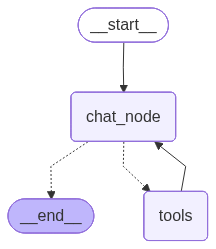

In [61]:
workflow

In [62]:

init = {
    "messages": [HumanMessage(content="Hello !!!")]
}

output = workflow.invoke(init)


In [54]:
print(output)
print(output["messages"][-1].content)



{'messages': [HumanMessage(content='Hello !!!', additional_kwargs={}, response_metadata={}, id='95f65cc8-ffa4-4e5d-921e-cc0940954a36'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 12, 'total_tokens': 22, 'completion_tokens': 10}, 'model_name': 'accounts/fireworks/models/llama-v3p1-8b-instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='run--764bfb9d-7f80-4dd4-8d25-31a192e019dd-0', usage_metadata={'input_tokens': 12, 'output_tokens': 10, 'total_tokens': 22})]}
Hello! How can I assist you today?


In [55]:
init = {
    "messages": [HumanMessage(content="What is 3*4?")]
}

output = workflow.invoke(init)

In [56]:
print(output)
print('*'*60)
print(output["messages"][-1].content)

{'messages': [HumanMessage(content='What is 3*4?', additional_kwargs={}, response_metadata={}, id='0e739768-9378-48b7-81a5-0aef2bb7c881'), AIMessage(content='3 * 4 = 12', additional_kwargs={}, response_metadata={'token_usage': {'prompt_tokens': 17, 'total_tokens': 25, 'completion_tokens': 8}, 'model_name': 'accounts/fireworks/models/llama-v3p1-8b-instruct', 'system_fingerprint': '', 'finish_reason': 'stop', 'logprobs': None}, id='run--e515302d-b07f-4353-b3b6-25c0c1a8f24b-0', usage_metadata={'input_tokens': 17, 'output_tokens': 8, 'total_tokens': 25})]}
************************************************************
3 * 4 = 12


In [63]:
init = {
    "messages": [HumanMessage(content="What is the stock price of apple")]
}

output = workflow.invoke(init)

In [58]:
print(output)
print("*"*60)
print(output["messages"][-1].content)

{'messages': [HumanMessage(content='What is the stock price of apple', additional_kwargs={}, response_metadata={}, id='b83bf6cb-3486-41a0-8635-13e7263f605c'), AIMessage(content='I don\'t have access to real-time market data, but I can suggest some ways for you to find the current stock price of Apple.\n\nYou can check the current stock price of Apple (AAPL) on various financial websites, such as:\n\n1. **Yahoo Finance**: [finance.yahoo.com](http://finance.yahoo.com)\n2. **Google Finance**: [finance.google.com](http://finance.google.com)\n3. **NASDAQ**: [www.nasdaq.com](http://www.nasdaq.com)\n4. **Apple\'s investor relations website**: [investor.apple.com](http://investor.apple.com)\n\nJust enter "AAPL" in the search bar, and you\'ll see the current stock price, along with other relevant information such as market capitalization, trading volume, and more.\n\nPlease note that stock prices can fluctuate rapidly, so the price may change between the time I provide this information and when